# Support Vector Machines

In questo notebook studiamo le **Support Vector Machines**, abbreviate in **SVM**.

Le SVM sono algoritmi di classificazione supervisionata. Nel caso più semplice, vengono usate per risolvere problemi di classificazione binaria.

L'idea principale è trovare un iperpiano che separi due classi cercando di massimizzare il margine tra esse.

Nel caso bidimensionale, l'iperpiano è una retta.

Nel caso tridimensionale, l'iperpiano è un piano.

In dimensioni maggiori, si parla genericamente di iperpiano.

L'obiettivo della SVM non è soltanto separare correttamente le classi, ma trovare la separazione che lascia più spazio possibile tra le classi.

## Classificazione binaria e iperpiano

Nel contesto della classificazione binaria consideriamo due classi:

$$
y \in \{-1, +1\}
$$

Assumiamo inizialmente che le due classi siano separabili linearmente.

L'iperpiano di separazione è definito da:

$$
H: w \cdot x + w_0 = 0
$$

dove:

- $x$ è il vettore delle feature di un esempio;
- $w$ è il vettore dei pesi;
- $w_0$ è il bias, o intercetta;
- $w \cdot x$ indica il prodotto scalare tra $w$ e $x$.

La predizione viene fatta guardando il segno di:

$$
w \cdot x + w_0
$$

Se:

$$
w \cdot x + w_0 \geq 0
$$

allora l'esempio viene assegnato alla classe $+1$.

Se:

$$
w \cdot x + w_0 < 0
$$

allora l'esempio viene assegnato alla classe $-1$.

## Margine massimo

La SVM non cerca un iperpiano qualsiasi.

Cerca l'iperpiano che massimizza il margine tra le due classi.

Consideriamo due iperpiani paralleli all'iperpiano decisionale:

$$
H^+: w \cdot x^+ + w_0 = +1
$$

$$
H^-: w \cdot x^- + w_0 = -1
$$

Gli esempi che si trovano su questi iperpiani sono detti **vettori di supporto**.

La distanza tra i due iperpiani $H^+$ e $H^-$ è:

$$
\frac{2}{||w||}
$$

Quindi massimizzare il margine equivale a massimizzare:

$$
\frac{2}{||w||}
$$

che equivale a minimizzare:

$$
\frac{1}{2}||w||^2
$$

La SVM cerca quindi un compromesso tra classificare correttamente gli esempi e mantenere piccolo il vettore dei pesi.

## Vettori di supporto

I **vettori di supporto** sono gli esempi più vicini all'iperpiano decisionale.

Sono importanti perché determinano la posizione del margine e quindi dell'iperpiano.

Nel caso linearmente separabile:

- alcuni esempi della classe $+1$ si trovano sull'iperpiano $H^+$;
- alcuni esempi della classe $-1$ si trovano sull'iperpiano $H^-$.

Questi punti soddisfano:

$$
w \cdot x^{+} + w_0 = +1
$$

oppure:

$$
w \cdot x^{-} + w_0 = -1
$$

Gli altri punti, più lontani dal margine, hanno meno influenza sulla posizione finale dell'iperpiano.

## Vincolo della SVM linearmente separabile

Per una SVM lineare con classi $-1$ e $+1$, possiamo scrivere un unico vincolo:

$$
y^{(i)}(w \cdot x^{(i)} + w_0) \geq 1
$$

per ogni esempio $i$.

Infatti, se:

$$
y^{(i)} = +1
$$

allora il vincolo diventa:

$$
w \cdot x^{(i)} + w_0 \geq 1
$$

Se invece:

$$
y^{(i)} = -1
$$

allora il vincolo diventa:

$$
w \cdot x^{(i)} + w_0 \leq -1
$$

Il termine:

$$
y^{(i)}(w \cdot x^{(i)} + w_0)
$$

viene spesso chiamato **margine funzionale**.

Se è maggiore o uguale a $1$, l'esempio è classificato correttamente e si trova fuori dal margine.

## Casi non separabili linearmente

Nella pratica i dati non sono sempre perfettamente separabili da una retta o da un iperpiano.

In questi casi i vincoli della SVM linearmente separabile potrebbero non avere soluzione.

Per gestire questi casi introduciamo le **slack variables**:

$$
\xi^{(i)} \geq 0
$$

Queste variabili permettono di ammorbidire i vincoli.

Per la classe positiva:

$$
w \cdot x^{(i)} + w_0 \geq 1 - \xi^{(i)}
$$

Per la classe negativa:

$$
w \cdot x^{(i)} + w_0 \leq -1 + \xi^{(i)}
$$

In forma compatta:

$$
y^{(i)}(w \cdot x^{(i)} + w_0) \geq 1 - \xi^{(i)}
$$

Se $\xi^{(i)} = 0$, l'esempio rispetta il margine.

Se $\xi^{(i)} > 0$, l'esempio viola il margine o può essere classificato male.

## Funzione obiettivo con slack variables

Introducendo le slack variables, la funzione obiettivo diventa:

$$
\frac{1}{2}||w||^2 + C \sum_{i=1}^{n} \xi^{(i)}
$$

Il primo termine:

$$
\frac{1}{2}||w||^2
$$

serve a massimizzare il margine.

Il secondo termine:

$$
C \sum_{i=1}^{n} \xi^{(i)}
$$

penalizza le violazioni del margine.

L'iperparametro $C$ controlla il compromesso tra margine ed errori.

Se $C$ è grande:

- gli errori vengono penalizzati molto;
- il modello cerca di classificare correttamente più punti possibile;
- il margine può diventare più stretto;
- aumenta il rischio di overfitting.

Se $C$ è piccolo:

- gli errori vengono tollerati di più;
- il margine può essere più largo;
- il modello è più regolarizzato;
- aumenta il rischio di underfitting.

## Hinge loss

Per eliminare i vincoli espliciti, le slack variables possono essere sostituite dalla **hinge loss**.

Per ogni esempio:

$$
\xi^{(i)} =
\max \left(0, 1 - y^{(i)}(w \cdot x^{(i)} + w_0)\right)
$$

Se:

$$
y^{(i)}(w \cdot x^{(i)} + w_0) \geq 1
$$

allora:

$$
\xi^{(i)} = 0
$$

L'esempio è classificato correttamente e rispetta il margine.

Se invece:

$$
y^{(i)}(w \cdot x^{(i)} + w_0) < 1
$$

allora la hinge loss diventa positiva.

Questo significa che l'esempio viola il margine oppure è classificato male.

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
import numpy as np
import pandas as pd
from time import time


def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', '*', 'o', '^', 'v', '*')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

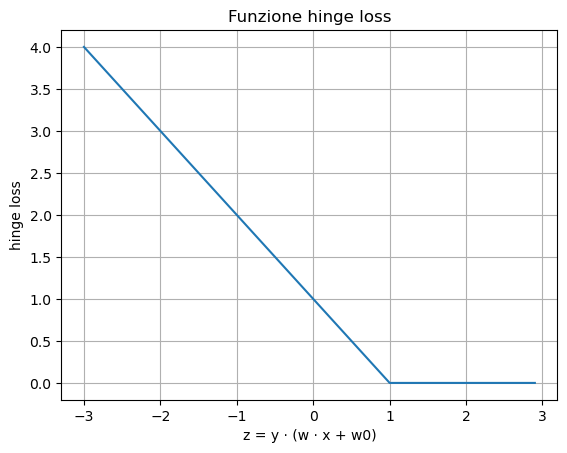

In [110]:
def hinge_loss_value(z):
    return max(0, 1 - z)


z_values = np.arange(-3, 3, 0.1)
loss_values = [hinge_loss_value(z) for z in z_values]

plt.plot(z_values, loss_values)
plt.xlabel("z = y · (w · x + w0)")
plt.ylabel("hinge loss")
plt.title("Funzione hinge loss")
plt.grid(True)
plt.show()

## Interpretazione della hinge loss

Nel grafico abbiamo indicato con:

$$
z = y(w \cdot x + w_0)
$$

il margine funzionale dell'esempio.

La hinge loss è:

$$
\max(0, 1-z)
$$

Se:

$$
z \geq 1
$$

allora la loss vale $0$.

Questo significa che l'esempio è classificato correttamente e si trova fuori dal margine.

Se:

$$
z < 1
$$

allora la loss è positiva.

Questo include due casi:

1. l'esempio è classificato correttamente, ma si trova dentro il margine;
2. l'esempio è classificato male.

Quindi la SVM non penalizza solo gli errori di classificazione, ma anche i punti troppo vicini all'iperpiano.

## Funzione obiettivo finale

Sostituendo le slack variables con la hinge loss, la funzione obiettivo diventa:

$$
J(w) =
\frac{1}{2}||w||^2
+
C \sum_{i=1}^{n}
\max \left(0, 1 - y^{(i)}(w \cdot x^{(i)} + w_0)\right)
$$

Questa funzione contiene due componenti:

1. un termine di regolarizzazione:

$$
\frac{1}{2}||w||^2
$$

2. un termine di errore basato sulla hinge loss:

$$
C \sum_{i=1}^{n}
\max \left(0, 1 - y^{(i)}(w \cdot x^{(i)} + w_0)\right)
$$

L'obiettivo dell'addestramento è minimizzare $J(w)$.

## Discesa del gradiente

Per addestrare la SVM dobbiamo minimizzare la funzione obiettivo:

$$
J(w) =
\frac{1}{2}||w||^2
+
C \sum_{i=1}^{n}
\max \left(0, 1 - y^{(i)}(w \cdot x^{(i)} + w_0)\right)
$$

La funzione obiettivo contiene due parti:

1. un termine di regolarizzazione:

$$
\frac{1}{2}||w||^2
$$

2. un termine di errore basato sulla hinge loss:

$$
C \sum_{i=1}^{n}
\max \left(0, 1 - y^{(i)}(w \cdot x^{(i)} + w_0)\right)
$$

La discesa del gradiente aggiorna i pesi muovendosi nella direzione opposta al gradiente della funzione costo:

$$
w := w - \eta \frac{\partial J}{\partial w}
$$

dove $\eta$ è il learning rate.

## Derivata della funzione obiettivo

La derivata del primo termine è:

$$
\frac{d}{dw_j} \frac{1}{2}||w||^2 = w_j
$$

La parte più importante riguarda la hinge loss:

$$
\max\left(0, 1 - y^{(i)}(w \cdot x^{(i)} + w_0)\right)
$$

La derivata dipende dal valore di:

$$
1 - y^{(i)}(w \cdot x^{(i)} + w_0)
$$

Se:

$$
1 - y^{(i)}(w \cdot x^{(i)} + w_0) < 0
$$

allora il punto è classificato correttamente e rispetta il margine. La hinge loss vale zero, quindi la sua derivata è zero.

Se invece:

$$
1 - y^{(i)}(w \cdot x^{(i)} + w_0) \geq 0
$$

allora il punto viola il margine oppure è classificato male. In questo caso la derivata della hinge loss rispetto a $w_j$ è:

$$
-y^{(i)}x_j^{(i)}
$$

La derivata della sommatoria non può essere generalizzata perché dipende dal segno di

$$
1-y^{(i)}( w\cdot x^{(i)} + w_0 ).
$$


Se $1-y^{(i)}( w\cdot x^{(i)} + w_0 ) < 0$ (esempio classificato correttamente)

$$
\frac{d}{d w_j} \max\left(0, 1 - y^{(i)}(w\cdot x^{(i)} + w_0) \right) = 0.
$$

Se $1-y^{(i)}( w\cdot x^{(i)} + w_0 ) \geq 0$

$$
\frac{d}{d w_j} \max\left(0, 1 - y^{(i)}(w\cdot x^{(i)} + w_0) \right) = -y^{(i)}x_j^{(i)}.
$$

Questo ci fornisce un metodo su come aggiornare il pesi $w$: usando un approccio stocastico, per ogni nuovo esempio $x^{(i)}$

$$
w  \leftarrow \left\{
\begin{array}{lcl}
w - \eta w & & \text{se $y^{(i)}( w\cdot x^{(i)} + w_0 ) > 1$}\\
w - \eta \left(w  - C y^{(i)} x^{(i)} \right) & & \text{altrimenti}
\end{array}
\right.
$$

## Regole di aggiornamento

Usando un approccio stocastico, il modello aggiorna i pesi esempio per esempio.

Per ogni esempio $x^{(i)}$ calcoliamo il margine:

$$
margin = y^{(i)}(w \cdot x^{(i)} + w_0)
$$

Se:

$$
margin > 1
$$

l'esempio è corretto e fuori dal margine. In questo caso si applica solo il termine di regolarizzazione:

$$
w \leftarrow w - \eta w
$$

Se invece:

$$
margin \leq 1
$$

l'esempio viola il margine oppure è classificato male. In questo caso l'aggiornamento diventa:

$$
w \leftarrow w - \eta(w - C y^{(i)}x^{(i)})
$$

Nel codice della lezione viene usata la condizione `margin >= 1` per il primo caso e `else` per il secondo.

## Interpretazione

Quando un punto rispetta il margine, la hinge loss è nulla.

Il modello non deve correggere la classificazione di quel punto. L'unico effetto è la riduzione dei pesi dovuta alla regolarizzazione.

Quando invece il punto viola il margine, la hinge loss è positiva.

In quel caso l'aggiornamento contiene anche il termine:

$$
C y^{(i)}x^{(i)}
$$

che spinge l'iperpiano a classificare meglio l'esempio corrente.

L'iperparametro $C$ controlla quanto pesano queste correzioni:

- valori grandi di $C$ penalizzano molto le violazioni del margine;
- valori piccoli di $C$ tollerano maggiormente le violazioni.

In [111]:
class SVM(object):
    """Support Vector Machine (SVM) classifier using gradient descent."""

    
    def __init__(self, eta=0.01, n_iter=1000, C=1.0, random_state=1, tol=1e-4, verbose=True):
        self.eta = eta  # Learning rate
        self.n_iter = n_iter  # Number of iterations
        self.C = C  # Regularization parameter
        self.random_state = random_state
        self.tol = tol  # Tolerance for early stopping
        self.verbose = verbose  # Print iterations
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.last_cost = None
        
        for count in range(self.n_iter):
            cost = 0
            for xi, yi in zip(X, y):
                margin = yi * (np.dot(xi, self.w_[1:]) + self.w_[0])
                
                if margin >= 1:
                    self.w_ -= self.eta * self.w_ 
                else:
                    self.w_[1:] -= self.eta * (self.w_[1:] - self.C * yi * xi)  
                    self.w_[0] -= self.eta * (-self.C * yi)
                
                cost += max(0, 1 - margin)  
            
            if self.last_cost is not None and abs(cost - self.last_cost) < self.tol:
                if self.verbose:
                    print(f'Uscita anticipata dopo {count} iterazioni')
                break
            self.last_cost = cost
        
        return self
    
    def predict(self, X):
        return np.where(np.dot(X, self.w_[1:]) + self.w_[0] >= 0, 1, -1)

## Commento sul codice

Nel codice, il vettore `self.w_` contiene sia il bias sia i pesi:

- `self.w_[0]` è il bias;
- `self.w_[1:]` sono i pesi associati alle feature.

Il margine viene calcolato con:

```python
margin = yi * (np.dot(xi, self.w_[1:]) + self.w_[0])
```

che corrisponde alla formula:

$$
y^{(i)}(w \cdot x^{(i)} + w_0)
$$

Se `margin >= 1`, il punto rispetta il margine e viene applicato l'aggiornamento:

```python
self.w_ -= self.eta * self.w_
```

Se invece `margin < 1`, il punto viola il margine e vengono aggiornati separatamente:

```python
self.w_[1:] -= self.eta * (self.w_[1:] - self.C * yi * xi)
self.w_[0] -= self.eta * (-self.C * yi)
```

Il costo accumulato durante una iterazione è:

```python
cost += max(0, 1 - margin)
```

cioè la somma delle hinge loss sui singoli esempi.

## Costo computazionale dell'addestramento

Supponiamo di avere:

- `n` esempi;
- `d` feature;
- `T` iterazioni.

Per ogni esempio il codice calcola:

```python
np.dot(xi, self.w_[1:])
```

Il prodotto scalare ha costo:

$$
O(d)
$$

Anche l'aggiornamento dei pesi ha costo:

$$
O(d)
$$

Quindi il costo per un singolo esempio è:

$$
O(d)
$$

Il costo per una iterazione completa sul dataset è:

$$
O(n \cdot d)
$$

Il costo complessivo per `T` iterazioni è:

$$
O(T \cdot n \cdot d)
$$

La memoria per i parametri è:

$$
O(d)
$$

perché il modello memorizza un peso per ogni feature più il bias.

La memoria per il dataset è:

$$
O(n \cdot d)
$$

## Esempi

### Separabile

In [112]:
s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

In [113]:
# [0:50] iris-setosa
# [50:100] iris-versicolor
# [100:150] iris-virginica
y = df.iloc[:100, 4].values
y = np.where(y == 'Iris-versicolor', 1, -1)

# extract sepal length and petal length
X = df.iloc[:100, [0, 2]].values

X_std = (X-X.mean(0))/X.std(0)

Uscita anticipata dopo 8 iterazioni
Accuratezza: 1.0 
	Secondi: 0.002948760986328125


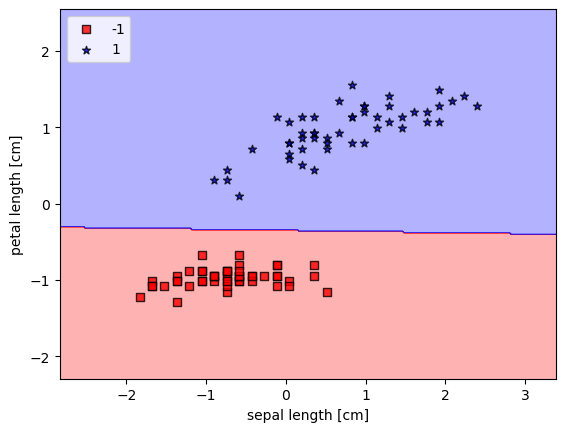

In [114]:
start_time = time()
svm = SVM(eta=0.001, C=1000, n_iter=1000, tol=0.01).fit(X_std, y)
end_time = time()
accuracy = np.mean(svm.predict(X_std) == y)
print('Accuratezza:', accuracy, '\n\tSecondi:', end_time-start_time)

plot_decision_regions(X_std, y, classifier=svm)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

In [115]:
# [0:50] iris-setosa
# [50:100] iris-versicolor
# [100:150] iris-virginica
y = df.iloc[50:, 4].values
y = np.where(y == 'Iris-versicolor', 1, -1)

# extract sepal length and petal length
X = df.iloc[50:, [0, 2]].values

X_std = (X-X.mean(0))/X.std(0)

Uscita anticipata dopo 7 iterazioni
Accuratezza: 0.9 
	Secondi: 0.002702951431274414


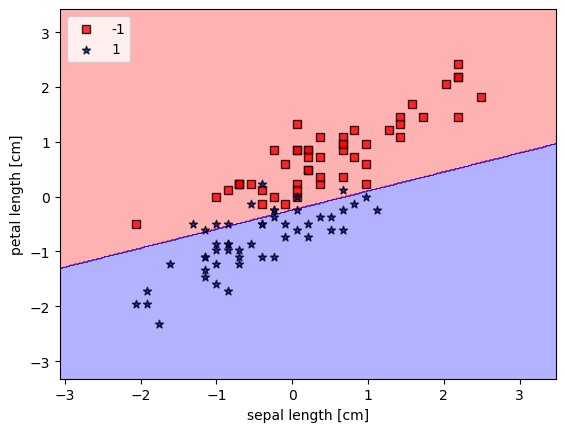

In [116]:
start_time = time()
svm = SVM(eta=0.001, C=100, n_iter=1000, tol=0.01).fit(X_std, y)
end_time = time()
accuracy = np.mean(svm.predict(X_std) == y)
print('Accuratezza:', accuracy, '\n\tSecondi:', end_time-start_time)

plot_decision_regions(X_std, y, classifier=svm)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

Testare altri valori dell'iper parametro `C`.

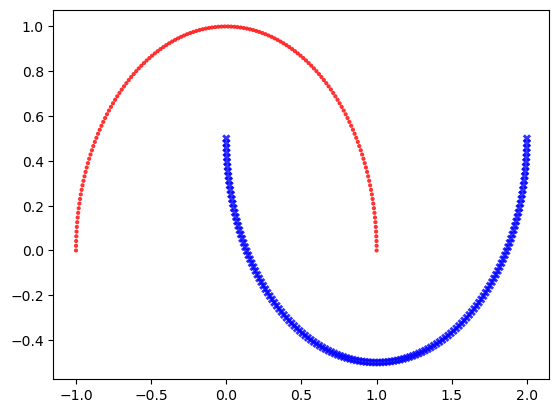

In [131]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.0, random_state=42)#modificando noise=0.x si ottiene un dataset più difficile da classificare, con i punti più sparsi e meno separabili linearmente.

markers=['.', 'X']
colors = ['r', 'b']

for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='none')

In [132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [133]:
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
print("Accuracy SVM lineare:", np.mean(y_test == y_pred_linear))


Accuracy SVM lineare: 0.8333333333333334


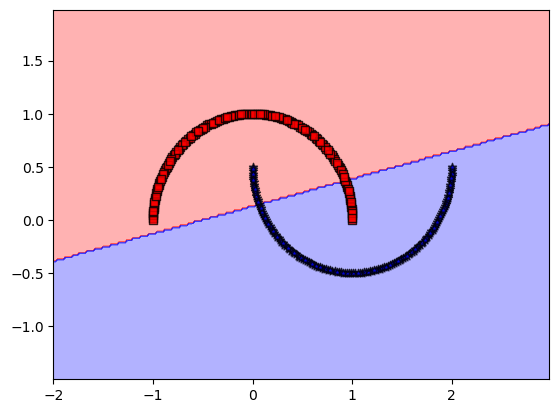

In [134]:
plot_decision_regions(X, y, linear_svm)

In [135]:
rbf_svm = SVC(kernel='rbf', gamma=1)
rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)
print("Accuracy SVM RBF:", np.mean(y_test == y_pred_rbf))

Accuracy SVM RBF: 1.0


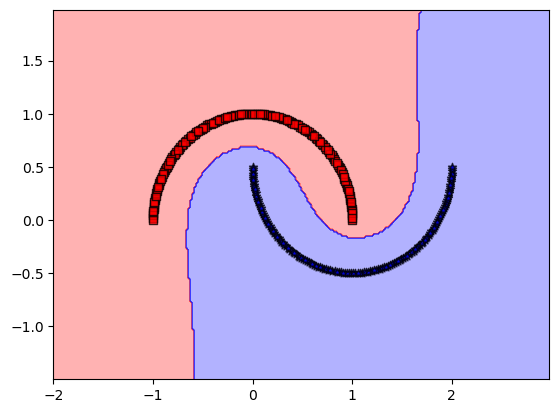

In [136]:
plot_decision_regions(X, y, rbf_svm)

## Kernel trick e classificazione non lineare

Una SVM lineare cerca un iperpiano nello spazio originale delle feature:

$$
w \cdot x + b = 0
$$

Questo funziona bene quando le classi sono linearmente separabili.

Quando i dati non sono separabili linearmente, possiamo trasformare gli input in uno spazio con più dimensioni tramite una funzione:

$$
\phi(x)
$$

La SVM cerca quindi un iperpiano nello spazio trasformato:

$$
w \cdot \phi(x) + b = 0
$$

Una separazione lineare nello spazio trasformato può corrispondere a una frontiera non lineare nello spazio originale.

Il problema è che calcolare esplicitamente $\phi(x)$ può essere molto costoso.

Il **kernel trick** permette di calcolare il prodotto scalare nello spazio trasformato senza costruire esplicitamente le nuove feature:

$$
K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)
$$

In questo modo possiamo ottenere frontiere decisionali non lineari mantenendo il problema gestibile.

## Kernel RBF

Uno dei kernel più usati è il kernel RBF, Radial Basis Function:

$$
K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)
$$

Questo kernel misura la similarità tra due punti in base alla loro distanza.

Se due punti sono vicini, il valore del kernel è vicino a 1.

Se due punti sono lontani, il valore del kernel tende a 0.

Il parametro $\gamma$ controlla quanto rapidamente diminuisce la similarità con la distanza.

- $\gamma$ piccolo: influenza più ampia, frontiera più liscia, rischio di underfitting;
- $\gamma$ grande: influenza più locale, frontiera più complessa, rischio di overfitting.

Con dataset non linearmente separabili, come `make_moons`, una SVM lineare non riesce a separare bene le classi, mentre una SVM con kernel RBF può costruire una frontiera decisionale curva.

## Esempio intuitivo: separazione circolare e aumento delle dimensioni

Supponiamo di avere un problema di classificazione binaria con due feature:

$$
x_1
$$

e:

$$
x_2
$$

I dati sono distribuiti in questo modo:

- la classe positiva si trova vicino all'origine;
- la classe negativa si trova più lontana dall'origine.

Graficamente, nello spazio bidimensionale, potremmo avere una situazione di questo tipo:

```text
Classe -1: punti esterni
Classe +1: punti interni


        -       -       -

    -       +   +   +       -

    -       +   +   +       -

        -       -       -
```

In questo caso non esiste una retta che separi correttamente le due classi.

Una retta può dividere il piano solo in due metà:

```text
classe A | classe B
```

ma qui la separazione naturale sarebbe una curva chiusa, per esempio un cerchio.

---

### Creazione di una nuova feature

Per rendere il problema separabile, possiamo costruire una nuova feature:

$$
x_3 = x_1^2 + x_2^2
$$

Questa nuova feature rappresenta, in pratica, la distanza quadratica del punto dall'origine.

I punti vicini all'origine avranno un valore basso di $x_3$.

I punti lontani dall'origine avranno un valore alto di $x_3$.

Quindi trasformiamo ogni punto da:

$$
(x_1, x_2)
$$

a:

$$
(x_1, x_2, x_1^2 + x_2^2)
$$

In questo modo passiamo da uno spazio bidimensionale a uno spazio tridimensionale.

---

### Separazione nello spazio trasformato

Nel nuovo spazio 3D, la separazione può diventare lineare.

Infatti, se la classe positiva è vicina all'origine e la classe negativa è lontana, possiamo separarle con un piano del tipo:

$$
x_3 = c
$$

dove $c$ è una soglia.

I punti con:

$$
x_3 < c
$$

vengono assegnati a una classe.

I punti con:

$$
x_3 \geq c
$$

vengono assegnati all'altra classe.

Quindi:

```text
Spazio originale 2D:
serve una curva, ad esempio un cerchio.

Spazio trasformato 3D:
basta un piano.
```

---

### Ritorno allo spazio originale

Nel nuovo spazio la separazione è:

$$
x_3 = c
$$

ma sappiamo che:

$$
x_3 = x_1^2 + x_2^2
$$

Quindi, tornando allo spazio originale, otteniamo:

$$
x_1^2 + x_2^2 = c
$$

Questa è l'equazione di un cerchio.

Quindi una separazione lineare nello spazio trasformato corrisponde a una separazione non lineare nello spazio originale.

---

### Collegamento con le SVM

La SVM cerca sempre un iperpiano lineare.

Tuttavia, se trasformiamo i dati tramite una funzione:

$$
\phi(x)
$$

la SVM può cercare un iperpiano nello spazio trasformato:

$$
w \cdot \phi(x) + b = 0
$$

Questa separazione è lineare nello spazio trasformato, ma può apparire come una curva nello spazio originale.

Il **kernel trick** permette di ottenere questo effetto senza costruire esplicitamente tutte le nuove feature.

L'idea chiave è:

```text
una frontiera non lineare nello spazio originale
può essere vista come
una frontiera lineare in uno spazio con più dimensioni
```